In [55]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [56]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-21,315.589996,0.0,315.589996,0.0,316.410004,313.950012,315.019989,0.0,20372300
2025-04-22,311.109985,0.0,311.109985,0.0,317.630005,310.359985,317.489990,0.0,35242300


In [57]:
finbert_score = pd.read_csv("../Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [58]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [59]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [60]:
merged_df = pd.merge(
    finbert_score, gold_data, left_on="Date", right_on="Date", how="inner"
)

In [61]:
df = merged_df[["Date", "Open"]]

df

,Date,Open
0,2004-11-18,44.430000
1,2004-11-19,44.490002
2,2004-11-22,44.750000
3,2004-11-23,44.880001
4,2004-11-24,44.930000
...,...,...
2914,2019-01-25,122.019997
2915,2019-01-28,122.750000
2916,2019-01-30,123.910004
2917,2019-01-31,125.180000


In [62]:
# make date the index
df.index = df.pop("Date")
df

,Open
Date,
2004-11-18,44.430000
2004-11-19,44.490002
2004-11-22,44.750000
2004-11-23,44.880001
2004-11-24,44.930000
...,...
2019-01-25,122.019997
2019-01-28,122.750000
2019-01-30,123.910004


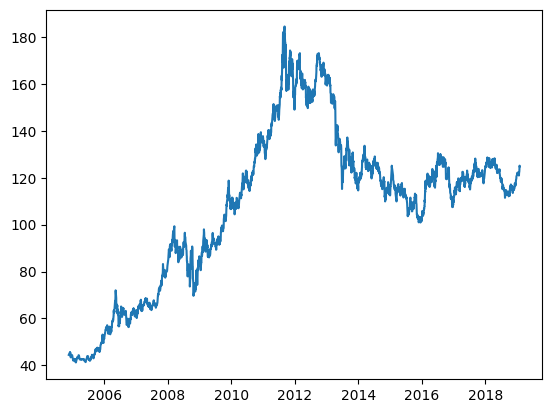

In [63]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Open"])

In [ ]:
import numpy as np
import pandas as pd


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe) - 1):  # Note the -1 to leave room for next day
        window = dataframe.iloc[i - n : i + 1]  # n previous + current row

        if len(window) != n + 1:
            continue  # skip if not enough data

        x_values = window[["Open"]].to_numpy()
        x = x_values[:-1]  # n previous values
        y = dataframe.iloc[i + 1]["Open"]  # next day's value

        dates.append(dataframe.index[i])  # the date corresponding to the last input day
        X.append(x.flatten())  # flatten to 1D array of n values
        Y.append(y)

    ret_df = pd.DataFrame({"Input Date": dates})

    X = np.array(X)  # shape (num_samples, n)
    for i in range(n):
        ret_df[f"Input-{n - i}"] = X[:, i]  # each column is Open value at t-n+i

    ret_df["Target"] = Y

    return ret_df

In [65]:
# import numpy as np
# import pandas as pd


# def df_to_windowed_df(dataframe, n=3):
#     dates = []
#     X, Y = [], []

#     for i in range(n, len(dataframe)):
#         window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

#         if len(window) != n + 1:
#             continue  # skip if not enough data

#         values = window[["Open"]].to_numpy()
#         x, y = values[:-1], values[-1][0]

#         dates.append(dataframe.index[i])  # the date corresponding to the target
#         X.append(x.flatten())  # flatten to 1D array of n values
#         Y.append(y)

#     ret_df = pd.DataFrame({"Target Date": dates})

#     X = np.array(X)  # shape (num_samples, n)
#     for i in range(n):
#         ret_df[f"Target-{n - i}"] = X[:, i]  # each column is Open value at t-n+i

#     ret_df["Target"] = Y

#     return ret_df

In [66]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Input Date,Input-3,Input-2,Input-1,Target
0,2004-11-23,44.430000,44.490002,44.750000,44.930000
1,2004-11-24,44.490002,44.750000,44.880001,45.099998
2,2004-11-29,44.750000,44.880001,44.930000,45.369999
3,2004-11-30,44.880001,44.930000,45.099998,45.279999
4,2004-12-01,44.930000,45.099998,45.369999,45.549999
...,...,...,...,...,...
2910,2019-01-24,121.739998,122.279999,120.959999,122.019997
2911,2019-01-25,122.279999,120.959999,121.160004,122.750000
2912,2019-01-28,120.959999,121.160004,122.019997,123.910004
2913,2019-01-30,121.160004,122.019997,122.750000,125.180000


In [ ]:
windowed_df = pd.merge(
    windowed_df, df, left_on="Input Date", right_on="Date", how="inner"
)

In [68]:
windowed_df.columns

Index(['Input Date', 'Input-3', 'Input-2', 'Input-1', 'Target', 'Open'], dtype='object')

In [ ]:
windowed_df = windowed_df[
    ["Input Date", "Input-3", "Input-2", "Input-1", "Open", "Target"]
]

In [70]:
# date, Input -> X, output -> Y
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    # getting the dates
    dates = df_as_np[:, 0]

    # we want the target window columns only and not the last one
    middle_matrix = df_as_np[:, 1:-1]
    # we need to reshape this
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    # ouput vector
    Y = df_as_np[:, -1]

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((2915,), (2915, 4, 1), (2915,))

In [71]:
dates

array([Timestamp('2004-11-23 00:00:00'), Timestamp('2004-11-24 00:00:00'),
       Timestamp('2004-11-29 00:00:00'), ...,
       Timestamp('2019-01-28 00:00:00'), Timestamp('2019-01-30 00:00:00'),
       Timestamp('2019-01-31 00:00:00')], dtype=object)

In [72]:
dates_test

array([Timestamp('2017-04-19 00:00:00'), Timestamp('2017-04-20 00:00:00'),
       Timestamp('2017-04-21 00:00:00'), Timestamp('2017-04-24 00:00:00'),
       Timestamp('2017-04-25 00:00:00'), Timestamp('2017-04-26 00:00:00'),
       Timestamp('2017-04-27 00:00:00'), Timestamp('2017-04-28 00:00:00'),
       Timestamp('2017-05-01 00:00:00'), Timestamp('2017-05-02 00:00:00'),
       Timestamp('2017-05-03 00:00:00'), Timestamp('2017-05-04 00:00:00'),
       Timestamp('2017-05-05 00:00:00'), Timestamp('2017-05-08 00:00:00'),
       Timestamp('2017-05-09 00:00:00'), Timestamp('2017-05-10 00:00:00'),
       Timestamp('2017-05-11 00:00:00'), Timestamp('2017-05-12 00:00:00'),
       Timestamp('2017-05-15 00:00:00'), Timestamp('2017-05-16 00:00:00'),
       Timestamp('2017-05-17 00:00:00'), Timestamp('2017-05-18 00:00:00'),
       Timestamp('2017-05-19 00:00:00'), Timestamp('2017-05-22 00:00:00'),
       Timestamp('2017-05-23 00:00:00'), Timestamp('2017-05-24 00:00:00'),
       Timestamp('2017-05

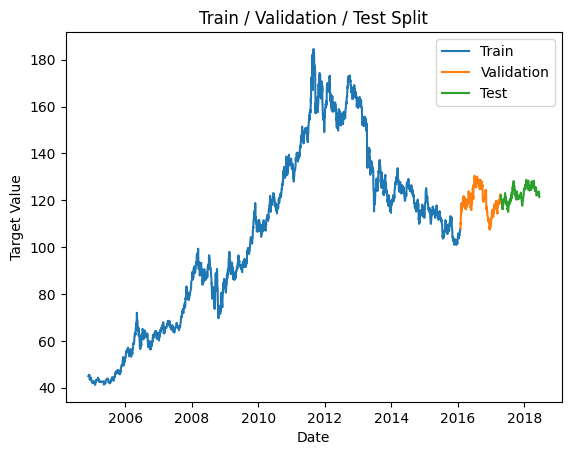

In [73]:
# training part
q_75 = int(len(dates) * 0.75)

# validation part
q_85 = int(len(dates) * 0.85)

# testing part
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_75], X[:q_75], y[:q_75]
dates_val, X_val, y_val = dates[q_75:q_85], X[q_75:q_85], y[q_75:q_85]
dates_test, X_test, y_test = dates[q_85:q_95], X[q_85:q_95], y[q_85:q_95]
dates_hold, X_hold, y_hold = dates[q_95:], X[q_95:], y[q_95:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.title("Train / Validation / Test Split")
plt.show()

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 1)),  # window size = 3, feature = 1
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12732.5488 - mean_absolute_error: 106.2942 - val_loss: 6214.5796 - val_mean_absolute_error: 78.6192
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3362.3137 - mean_absolute_error: 47.3903 - val_loss: 234.8264 - val_mean_absolute_error: 14.6047
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 480.6458 - mean_absolute_error: 14.8875 - val_loss: 4.9176 - val_mean_absolute_error: 1.9353
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5191 - mean_absolute_error: 1.6879 - val_loss: 2.2014 - val_mean_absolute_error: 1.1863
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.3485 - mean_absolute_error: 1.4808 - val_loss: 3.6712 - val_mean_absolute_error: 1.5802
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.9625 - mean_absolute_error: 1.4138 - val_loss: 2.3854 - val_mean_absolute_error: 1.2043
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.3992 - mean_absolute_erro

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


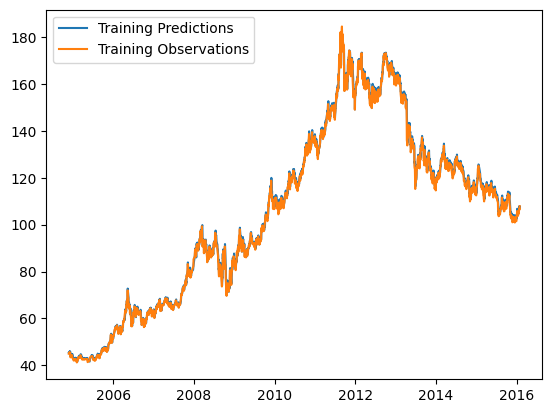

In [75]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

In [76]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
)
import numpy as np

mae = mean_absolute_error(y_train, train_predictions)
mse = mean_squared_error(y_train, train_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_predictions)
mape = mean_absolute_percentage_error(y_train, train_predictions)
explained_var = explained_variance_score(y_train, train_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1932
MSE: 2.7038
RMSE: 1.6443
R² Score: 0.9980
MAPE: 0.0113
Explained Variance: 0.9983


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


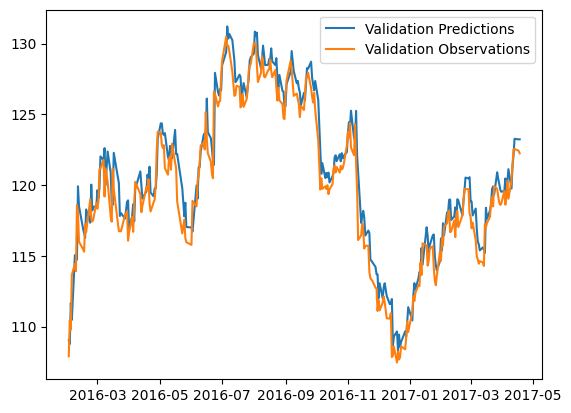

In [77]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

In [78]:
mae = mean_absolute_error(y_val, val_predictions)
mse = mean_squared_error(y_val, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_predictions)
mape = mean_absolute_percentage_error(y_val, val_predictions)
explained_var = explained_variance_score(y_val, val_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1865
MSE: 2.1761
RMSE: 1.4752
R² Score: 0.9265
MAPE: 0.0100
Explained Variance: 0.9495


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


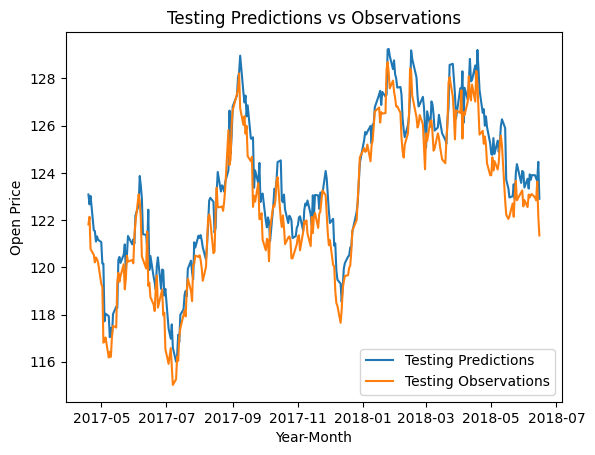

In [79]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])
plt.xlabel("Year-Month")  # x-axis label
plt.ylabel("Open Price")  # y-axis label
plt.title("Testing Predictions vs Observations")
plt.show()

In [80]:
mae = mean_absolute_error(y_test, test_predictions)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_predictions)
mape = mean_absolute_percentage_error(y_test, test_predictions)
explained_var = explained_variance_score(y_test, test_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 0.9350
MSE: 1.2823
RMSE: 1.1324
R² Score: 0.8713
MAPE: 0.0076
Explained Variance: 0.9407


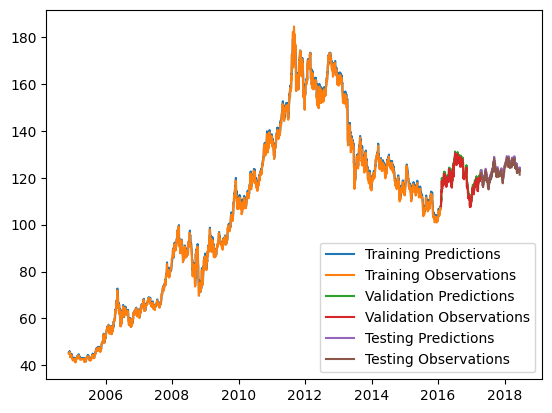

In [81]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
    ]
)

In [82]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

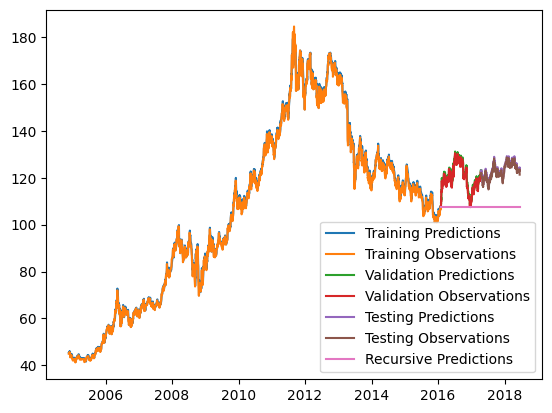

In [83]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
        "Recursive Predictions",
    ]
)